In [1]:
import math
import random
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image 
import PIL
import numpy as np
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf
import pickle
from tensorflow.keras import layers, models

# Details of the HyperParameters:
<ul>
    <li>Epochs controls the number of iterations for the training loop</li>
    <li>Batch_size controls images per batch for training</li>
    <li>Learning_rate determines how fast the model learns and approaches convergence. Optimal learning_rate for CGAN is 0.0002</li>
    <li>z_dim is the noise vector's dimension</li>
    <li>Image_channels is 3 in our case since we are dealing with RGB images</li>
    <li>Image_size controls the size of our image</li>
    <li>Size is the shape or the dimensions of an image</li>
    <li>NumClasses specify how many classes we are going to use. In our case, 7</li>

In [2]:
epochs = 50
batch_size = 16
z_dim = 128
img_channels = 3
image_size =  100
size = (3, 100, 100)
num_classes = 7

## Image Preprocessing and Normalizing and applying Appropriate Transformations

In [3]:
train_ds = image_dataset_from_directory(
    'Dataset/DATASET/train',
    labels='inferred',
    label_mode='categorical',
    batch_size=batch_size,
    image_size=(image_size,image_size),
    shuffle=True,
    seed=1337  # You can set a seed for reproducibility
)

# Normalization function
def normalize(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    img = (img - 0.5) / 0.5
    return img, label

# Apply the normalization
train_ds = train_ds.map(normalize)

# Prefetch and shuffle the dataset
train_ds = train_ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE).shuffle(1000)

Found 12271 files belonging to 7 classes.


In [4]:
def getInputDimensions(z_dim, shape, numClasses):
    generator_input_dim = z_dim + numClasses
    discriminator_input_dim = shape[0] + numClasses
    return generator_input_dim, discriminator_input_dim

In [5]:
generator_in_channels, discriminator_in_channels = getInputDimensions(128, (3, 100, 100), 7)

In [6]:
def make_gen_block(input_channels, output_channels, kernel_size=4, stride=2, padding='same', final_layer=False):
    if not final_layer:
        return [
            layers.Conv2DTranspose(output_channels, kernel_size, stride, padding),
            layers.BatchNormalization(),
            layers.ReLU()
        ]
    else:
        return [
            layers.Conv2DTranspose(output_channels, kernel_size, stride, padding, activation = 'tanh'),
        ]

hidden_dims = 128

generator = keras.Sequential([
    keras.layers.InputLayer((generator_in_channels,)),
    layers.Reshape((1, 1, generator_in_channels)),
    *make_gen_block(generator_in_channels, hidden_dims * 4, 4, 2),
    *make_gen_block(hidden_dims * 4, hidden_dims * 8, 4, 2),
    *make_gen_block(hidden_dims * 8, hidden_dims * 16, 4, 2),
    *make_gen_block(hidden_dims * 16, hidden_dims * 8, 4, 2),
    *make_gen_block(hidden_dims * 8, hidden_dims * 4, 10, 1, 'valid'),
    *make_gen_block(hidden_dims * 4, hidden_dims * 2, 4, 2),
    *make_gen_block(hidden_dims * 2, hidden_dims, 3, 1),
    *make_gen_block(hidden_dims, hidden_dims // 2, 4, 2),
    *make_gen_block(hidden_dims // 2, hidden_dims // 4, 3, 1),
    *make_gen_block(hidden_dims // 4, img_channels, 3, 1, final_layer=True)
], name="generator")

generator.summary()

Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 1, 1, 135)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 2, 2, 512)        1106432   
 nspose)                                                         
                                                                 
 batch_normalization (BatchN  (None, 2, 2, 512)        2048      
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 2, 2, 512)         0         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 4, 4, 1024)       8389632   
 ranspose)                                                       
                                                         

In [7]:
def make_crit_block(input_channels, output_channels, kernel_size=4, stride=2, padding=1, final_layer=False):
    if not final_layer:
        return [
            layers.Conv2D(output_channels, kernel_size, stride, 'same'),
            layers.BatchNormalization(),
            layers.LeakyReLU(alpha=0.2)
        ]
    else:
        return [
            layers.Conv2D(output_channels, kernel_size, stride, 'same')
        ]

hidden_dims = 32

discriminator = keras.Sequential([
    keras.layers.InputLayer((100, 100, discriminator_in_channels)),
    *make_crit_block(img_channels, hidden_dims),
    *make_crit_block(hidden_dims, hidden_dims * 2),
    *make_crit_block(hidden_dims * 2, hidden_dims * 4),
    *make_crit_block(hidden_dims * 4, hidden_dims * 8),
    *make_crit_block(hidden_dims * 8, hidden_dims * 16),
    *make_crit_block(hidden_dims * 16, 1, final_layer=True),
    layers.Flatten()
], name="discriminator")

discriminator.summary()

Model: "discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 50, 50, 32)        5152      
                                                                 
 batch_normalization_9 (Batc  (None, 50, 50, 32)       128       
 hNormalization)                                                 
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 50, 50, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 25, 25, 64)        32832     
                                                                 
 batch_normalization_10 (Bat  (None, 25, 25, 64)       256       
 chNormalization)                                                
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 25, 25, 64)      

In [8]:
def plot_images(images):
    num_images = len(images)
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow((images[i]).numpy())
        plt.axis('off')
    plt.show()

In [9]:
class ConditionalGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        real_images, one_hot_labels = data

        # Add dummy dimensions to the labels for concatenation with images
        image_one_hot_labels = one_hot_labels[:, :, None, None]
        image_one_hot_labels = tf.repeat(image_one_hot_labels, repeats=[image_size * image_size])
        image_one_hot_labels = tf.reshape(image_one_hot_labels, (-1, image_size, image_size, num_classes))

        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        random_vector_labels = tf.concat([random_latent_vectors, one_hot_labels], axis=1)

        generated_images = self.generator(random_vector_labels)

        fake_image_and_labels = tf.concat([tf.stop_gradient(generated_images), image_one_hot_labels], -1)
        real_image_and_labels = tf.concat([real_images, image_one_hot_labels], -1)

        with tf.GradientTape() as tape:
            predictions_fake = self.discriminator(fake_image_and_labels)
            predictions_real = self.discriminator(real_image_and_labels)
            d_loss_fake = self.loss_fn(tf.zeros_like(predictions_fake), predictions_fake)
            d_loss_real = self.loss_fn(tf.ones_like(predictions_real), predictions_real)
            d_loss = (d_loss_fake + d_loss_real) / 2
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        random_vector_labels = tf.concat([random_latent_vectors, one_hot_labels], axis=1)

        with tf.GradientTape() as tape:
            fake_images = self.generator(random_vector_labels)
            fake_image_and_labels = tf.concat([fake_images, image_one_hot_labels], -1)
            predictions = self.discriminator(fake_image_and_labels)
            g_loss = self.loss_fn(tf.ones_like(predictions), predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {"g_loss": self.gen_loss_tracker.result(), "d_loss": self.disc_loss_tracker.result()}

In [10]:
cgan = ConditionalGAN(discriminator, generator, 128)
cgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
)

In [11]:
cgan.load_weights('./ConditionalFacialGAN')

In [13]:
history = cgan.fit(train_ds, epochs=epochs)

Epoch 1/50
767/767 [==============================] - 1257s 2s/step - g_loss: 0.6927 - d_loss: 0.6950
Epoch 2/50
767/767 [==============================] - 1183s 1s/step - g_loss: 0.7215 - d_loss: 0.6970
Epoch 3/50
767/767 [==============================] - 1135s 1s/step - g_loss: 1.7473 - d_loss: 0.7125
Epoch 4/50
767/767 [==============================] - 1128s 1s/step - g_loss: 0.7527 - d_loss: 0.6954
Epoch 5/50
767/767 [==============================] - 1119s 1s/step - g_loss: 0.7101 - d_loss: 0.6971
Epoch 6/50
767/767 [==============================] - 1106s 1s/step - g_loss: 0.6889 - d_loss: 0.6975
Epoch 7/50
767/767 [==============================] - 1137s 1s/step - g_loss: 0.6987 - d_loss: 0.6950
Epoch 8/50
767/767 [==============================] - 1375s 2s/step - g_loss: 12.1478 - d_loss: 0.2988
Epoch 9/50
767/767 [==============================] - 1506s 2s/step - g_loss: 0.6868 - d_loss: 0.7063
Epoch 10/50
767/767 [==============================] - 1546s 2s/step - g_loss: 0.

KeyboardInterrupt: 

In [14]:
cgan.save_weights('./ConditionalFacialGAN')

In [15]:
class History_trained_model(object):
    def __init__(self, history, epoch, params):
        self.history = history
        self.epoch = epoch
        self.params = params

with open('History_FacialGAN', 'wb') as file:
    model_history = History_trained_model(history.history, history.epoch, history.params)
    pickle.dump(model_history, file, pickle.HIGHEST_PROTOCOL)

In [16]:
with open('History_FacialGAN', 'rb') as file:
    history = pickle.load(file)

print(history.history)

{'g_loss': [1.7988486289978027, 1.3213112354278564, 3.9482975006103516, 1.038338541984558, 1.2012313604354858, 1.8470922708511353, 1.1502983570098877, 4.838996410369873, 0.7834510803222656, 0.7340879440307617, 1.7218495607376099, 0.7596606612205505, 1.7163816690444946, 0.8813236951828003, 0.6914812922477722, 1.1124234199523926, 5.903960227966309, 1.0246607065200806, 0.7056329250335693, 0.6925796270370483, 0.7361376881599426, 1.3200620412826538, 0.7760962843894958, 3.9398579597473145, 0.718985378742218, 1.2659856081008911, 3.335637092590332, 0.7158324122428894, 0.6920790076255798, 0.6932435035705566], 'd_loss': [0.64579176902771, 0.6589933037757874, 0.45191583037376404, 0.6906508803367615, 0.6628021001815796, 0.6338199973106384, 0.6664188504219055, 0.5433863401412964, 0.733474850654602, 0.6980285048484802, 0.6376155614852905, 0.7223876714706421, 0.6070354580879211, 0.7071599364280701, 0.7016964554786682, 0.6993460059165955, 0.4370962679386139, 0.6833640336990356, 0.705966055393219, 0.69

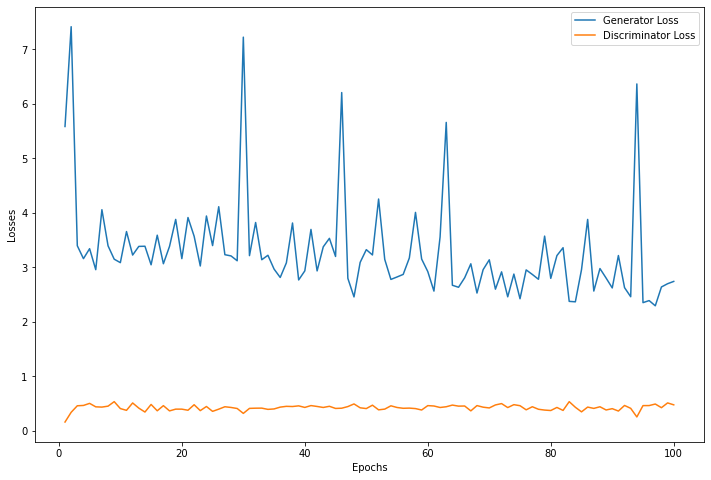

In [16]:
epochs = [i for i in range(1, 101)]
plt.figure(figsize = (12, 8))
plt.plot(epochs, history.history['g_loss'], label = 'Generator Loss')
plt.plot(epochs, history.history['d_loss'], label = 'Discriminator Loss')
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.legend()
plt.show()

In [12]:
# We first extract the trained generator from our Conditional GAN.
trained_gen = cgan.generator
num_classes = 7

# Choose the number of intermediate images that would be generated in
# between the interpolation + 2 (start and last images).
num_interpolation = 9  # @param {type:"integer"}
latent_dim = z_dim

# Sample noise for the interpolation.
interpolation_noise = tf.random.normal(shape=(1, latent_dim))
interpolation_noise = tf.repeat(interpolation_noise, repeats=num_interpolation, axis=0)
interpolation_noise = tf.reshape(interpolation_noise, (num_interpolation, latent_dim))

def interpolate_class(first_number, second_number):
    # Convert the start and end labels to one-hot encoded vectors.
    first_label = keras.utils.to_categorical([first_number], num_classes)
    second_label = keras.utils.to_categorical([second_number], num_classes)
    first_label = tf.cast(first_label, tf.float32)
    second_label = tf.cast(second_label, tf.float32)

    # Calculate the interpolation vector between the two labels.
    percent_second_label = tf.linspace(0.0, 1.0, num_interpolation)[:, None]
    percent_second_label = tf.cast(percent_second_label, tf.float32)
    interpolation_labels = first_label * (1 - percent_second_label) + second_label * percent_second_label

    # Combine the noise and the labels and run inference with the generator.
    noise_and_labels = tf.concat([interpolation_noise, interpolation_labels], axis=1)
    fake = trained_gen(noise_and_labels, training=False)
    return fake

start_class = 2  # @param {type:"slider", min:0, max:6, step:1}
end_class = 6  # @param {type:"slider", min:0, max:6, step:1}

fake_images = interpolate_class(start_class, end_class)
fake_images = ((fake_images * 0.5) + 0.5) * 255.0
fake_images = fake_images.numpy()
fake_images = fake_images.astype(np.uint8)

In [13]:
images = Image.fromarray(fake_images[3])

In [12]:
def generate(cls):
    generator = cgan.generator
    for i in range(5):
        noise = tf.random.normal(shape = (1, z_dim))
        label = keras.utils.to_categorical([cls], 7)
        label = tf.cast(label, tf.float32)
        noise_and_labels = tf.concat([noise, label], axis=1)
        generated_images = generator(noise_and_labels, training = False)
        fake_images = ((generated_images * 0.5) + 0.5) * 255.0
        fake_images = fake_images.numpy()
        fake_images = fake_images.astype(np.uint8)
        fake_image = Image.fromarray(fake_images[0])
        fake_image.save('Generated/' + str(cls + 1) + '/image_' + str(i + 1) + '.jpg')

## In the third line, you can change [3] to any class you want, from 0-6 since we have a total of 7 classes. To save the image, you can run the following cell

In [13]:
for i in range(7):
    generate(i)

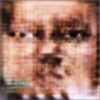

In [50]:
fake_image

# Results

## From the graph, it is clear that the both the Generator and the Discriminator have converged. The current results are not so good indicating Mode Collapse as well as overfitting to the data. Mode Collapse happens when the Generator starts producing the same samples for different classes. Binary Cross Entropy loss has this problem. Since the MNIST dataset is a very simple dataset, so BCE loss works well but the Human Faces dataset is very complex and requires detailed architectures as well as good loss functions so the BCE loss can drastically reduce the training progress. We can see that for the different classes, the generator produces similar samples which appear same to the eye but have very minor pixel intensity value differences. All in all, more complex architectures, along with Wasserstein Loss are preferred for better training performance. One option could be to use StyleGAN but for 100x100 images, it is overkill and will prove to be very expensive